In [43]:
## Imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_v2 = pd.read_csv("dataset version 2 (v2).")
train_data_v2 = pd.read_csv("train dataset(v2)")
test_data_v2 = pd.read_csv("test dataset(v2)")

In [2]:
## Check head

data_v2.head()

,Unnamed: 0,region,gender,age,height,weight,candj,snatch,deadlift,backsq,eat,train,background,experience,schedule,howlong,total lift
0,21,Southern California,Male,30.0,71.0,200.0,235.0,175.0,385.0,315.0,I eat whatever is convenient|,I workout mostly at a CrossFit Affiliate|I inc...,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I do multiple workouts in a day 1x a week|I ty...,1-2 years|,1110.0
1,22,Africa,Male,28.0,70.0,176.0,187.0,134.0,335.0,254.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 1x a week|,2-4 years|,910.0
2,27,North East,Male,35.0,68.0,225.0,285.0,205.0,440.0,405.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I typically rest 4 or more days per month|,2-4 years|,1335.0
3,50,North Central,Male,36.0,71.0,199.0,267.0,212.0,485.0,390.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I p...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 3+ times a wee...,1-2 years|,1354.0
4,60,North East,Male,36.0,64.0,155.0,245.0,180.0,415.0,385.0,I eat strict Paleo|,"I workout mostly at home, work, or a tradition...",I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I do multiple workouts in a day 2x a week|I st...,4+ years|,1225.0


In [3]:
## Check Columns

data_v2.columns

Index(['Unnamed: 0', 'region', 'gender', 'age', 'height', 'weight', 'candj',
       'snatch', 'deadlift', 'backsq', 'eat', 'train', 'background',
       'experience', 'schedule', 'howlong', 'total lift'],
      dtype='object')

In [4]:
## Check Shape

data_v2.shape, train_data_v2.shape, test_data_v2.shape

((30161, 17), (24128, 8), (6033, 8))

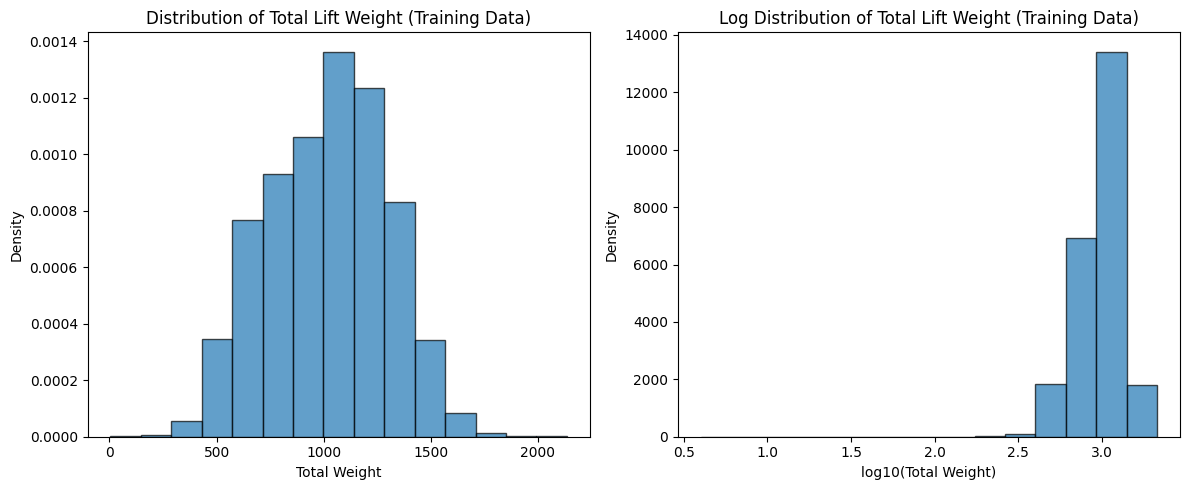

In [5]:
## Check distribution of total lifts(Train)

data = train_data_v2['total lift']
data_nonzero = data[data > 0]

plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(data, bins=15, density=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Lift Weight (Training Data)')
plt.xlabel('Total Weight')
plt.ylabel('Density')

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(np.log10(data_nonzero), bins=15, edgecolor='black', alpha=0.7)
plt.title('Log Distribution of Total Lift Weight (Training Data)')
plt.xlabel('log10(Total Weight)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

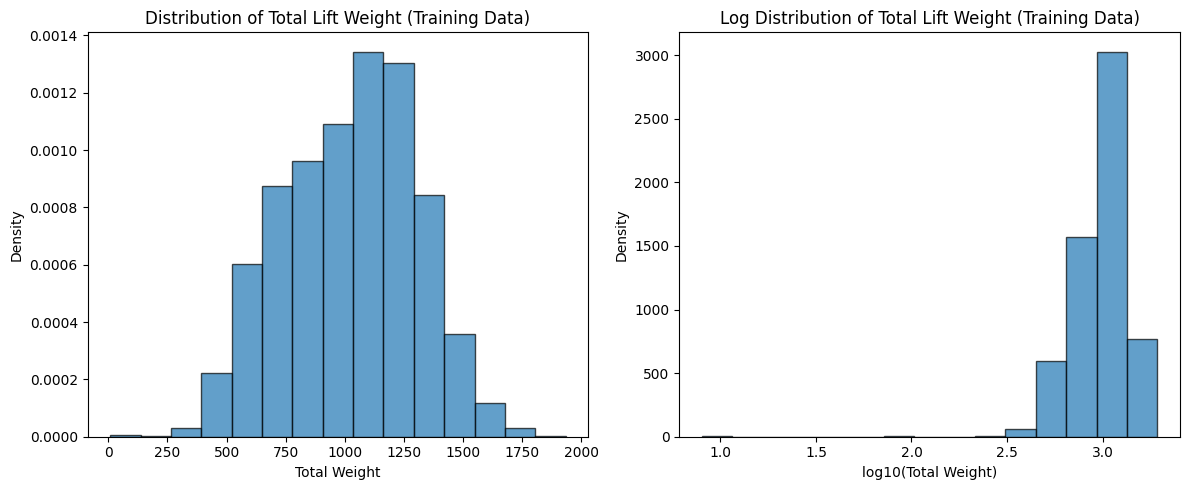

In [6]:
## Check distribution of total lifts(Test)

data = test_data_v2['total lift']
data_nonzero = data[data > 0]

plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(data, bins=15, density=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Lift Weight (Training Data)')
plt.xlabel('Total Weight')
plt.ylabel('Density')

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(np.log10(data_nonzero), bins=15, edgecolor='black', alpha=0.7)
plt.title('Log Distribution of Total Lift Weight (Training Data)')
plt.xlabel('log10(Total Weight)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [11]:
## Check Correlations

## Clean up

clean = data_v2.copy()

clean = clean.dropna(subset=['region','age','weight','height','howlong','gender','eat', \
                               'background','experience','schedule','howlong', \
                               'deadlift','candj','snatch','backsq','experience',\
                               'background','schedule','howlong'])

clean = clean.drop(columns=['Unnamed: 0', 'gender', 'eat', 'train', 'background', 'experience', 'schedule', \
                            'howlong', 'region'])


corr = clean.corr()
corr

,age,height,weight,candj,snatch,deadlift,backsq,total lift
age,1.000000,0.028893,0.093488,-0.196991,-0.204352,-0.091542,-0.113767,-0.144320
height,0.028893,1.000000,0.705066,0.519655,0.491602,0.541460,0.477596,0.531254
weight,0.093488,0.705066,1.000000,0.567489,0.532342,0.624648,0.613115,0.619033
candj,-0.196991,0.519655,0.567489,1.000000,0.951828,0.883051,0.907549,0.964451
snatch,-0.204352,0.491602,0.532342,0.951828,1.000000,0.847135,0.876065,0.940582
deadlift,-0.091542,0.541460,0.624648,0.883051,0.847135,1.000000,0.902161,0.960418
backsq,-0.113767,0.477596,0.613115,0.907549,0.876065,0.902161,1.000000,0.966573
total lift,-0.144320,0.531254,0.619033,0.964451,0.940582,0.960418,0.966573,1.000000


## Baseline

In [52]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

## Clean Up

trainv2 = train_data_v2.drop(['Unnamed: 0'], axis=1)
trainv2 = trainv2.dropna()

testv2 = test_data_v2.drop(['Unnamed: 0'], axis=1)
testv2 = testv2.dropna()

X_train = trainv2.drop(columns=['total lift'])
y_train = trainv2['total lift']

X_test = testv2.drop(columns=['total lift'])
y_test = testv2['total lift']

In [15]:
## Pipeline

cat_features = ['region', 'gender', 'howlong']
num_features = ['age', 'weight', 'height']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'gender',
                                                   'howlong'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [19]:
## Save model

import pickle

# Save model
with open("trained_total_lift_model_v2.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model pipeline saved as 'trained_total_lift_model_v2.pkl'")

✅ Model pipeline saved as 'trained_total_lift_model_v2.pkl'


## Metrics

In [16]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

n = len(y_test)       
p = X_test.shape[1]   
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R²', 'Adjusted R²'],
    'Value': [mae, mse, rmse, mape, r2, adj_r2]
})

print("\n Model Performance on Test Set:")
print(metrics.to_string(index=False))


 Model Performance on Test Set:
     Metric        Value
        MAE   126.791354
        MSE 27688.991118
       RMSE   166.400094
       MAPE     0.174559
         R²     0.645475
Adjusted R²     0.645122


In [20]:
metrics.to_csv("model_metrics_v2.csv", index=False)
print("Metrics saved to 'model_metrics_v2.csv'")

Metrics saved to 'model_metrics_v2.csv'


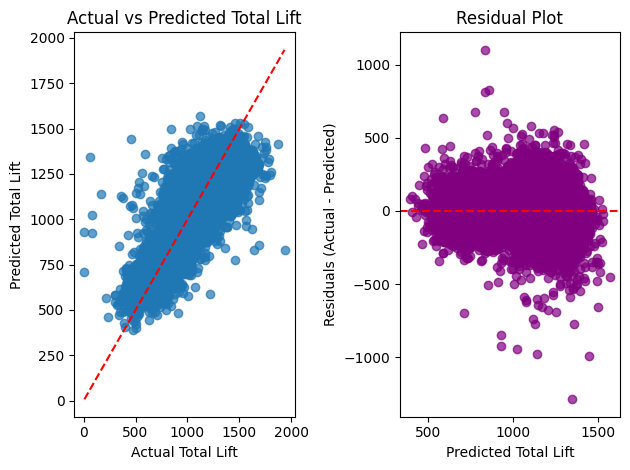

In [17]:
# 1️⃣ Actual vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Lift")
plt.ylabel("Predicted Total Lift")
plt.title("Actual vs Predicted Total Lift")

# 2️⃣ Residuals Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Total Lift")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

## Calculate DP

In [55]:
## Prepare Data

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from opacus import PrivacyEngine
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import pandas as pd
import numpy as np
import math

cat_features = ['region', 'gender', 'howlong']
num_features = ['age', 'weight', 'height']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
], remainder='passthrough')

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

scaler = StandardScaler()
X_train_proc[:, -len(num_features):] = scaler.fit_transform(X_train_proc[:, -len(num_features):])
X_test_proc[:, -len(num_features):] = scaler.transform(X_test_proc[:, -len(num_features):])

X_train_tensor = torch.tensor(X_train_proc.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values.astype(np.float32)).view(-1,1)
X_test_tensor = torch.tensor(X_test_proc.astype(np.float32))
y_test_tensor = torch.tensor(y_test.values.astype(np.float32)).view(-1,1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

In [56]:
## Build Model

input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [58]:
## DP-SGD

batch_size = 64
epochs = 20
learning_rate = 0.01
noise_multiplier = 1.1
max_grad_norm = 1.0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Updated PrivacyEngine API
from opacus import PrivacyEngine
privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=noise_multiplier,
    max_grad_norm=max_grad_norm,
)

criterion = nn.MSELoss()



/Users/leontan/opt/anaconda3/lib/python3.9/site-packages/opacus/privacy_engine.py:142: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [59]:
## Train DP Model

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_dataset):.4f}")

/Users/leontan/opt/anaconda3/lib/python3.9/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


Epoch 1/20, Loss: 1105700.8397
Epoch 2/20, Loss: 1074483.9718
Epoch 3/20, Loss: 954140.9445
Epoch 4/20, Loss: 698272.9918
Epoch 5/20, Loss: 358550.4381
Epoch 6/20, Loss: 97452.9811
Epoch 7/20, Loss: 38629.8567
Epoch 8/20, Loss: 33007.6738
Epoch 9/20, Loss: 32167.6682
Epoch 10/20, Loss: 31286.8650
Epoch 11/20, Loss: 30814.4309
Epoch 12/20, Loss: 30345.4223
Epoch 13/20, Loss: 29937.2293
Epoch 14/20, Loss: 29012.3003
Epoch 15/20, Loss: 29015.3830
Epoch 16/20, Loss: 28232.6206
Epoch 17/20, Loss: 27929.1065
Epoch 18/20, Loss: 27596.7907
Epoch 19/20, Loss: 28169.0676
Epoch 20/20, Loss: 27619.7586


In [63]:
## Compute DP epsilon

delta = 1 / len(train_dataset)
epsilon = privacy_engine.get_epsilon(delta)
print(f"DP-SGD epsilon: {epsilon:.4f}, delta: {delta:.5f}")


DP-SGD epsilon: 0.9139, delta: 0.00004


/Users/leontan/opt/anaconda3/lib/python3.9/site-packages/opacus/accountants/analysis/prv/prvs.py:50: RuntimeWarning: invalid value encountered in log
  z = np.log((np.exp(t) + q - 1) / q)


In [64]:
## Metrics

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy().reshape(-1)

mae = mean_absolute_error(y_test_tensor, y_pred_test)
mse = mean_squared_error(y_test_tensor, y_pred_test)
rmse = math.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_tensor, y_pred_test)
r2 = r2_score(y_test_tensor, y_pred_test)
adj_r2 = 1 - (1 - r2) * (len(y_test_tensor)-1) / (len(y_test_tensor)-input_dim-1)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R²', 'Adjusted R²', 'DP epsilon', 'DP delta'],
    'Value': [mae, mse, rmse, mape, r2, adj_r2, float(epsilon), float(1/len(train_dataset))]
})

print("\nDP Model Performance on Test Set:")
print(metrics.to_string(index=False))


DP Model Performance on Test Set:
     Metric        Value
        MAE   129.149933
        MSE 27975.267578
       RMSE   167.258087
       MAPE     0.180458
         R²     0.641810
Adjusted R²     0.639057
 DP epsilon     0.913860
   DP delta     0.000041
